In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.shape

(9994, 21)

### Converting column name to lower case


In [6]:
df.columns=df.columns.str.replace(' ','_').str.lower()

In [7]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [8]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Creating a temporary SQLite database in RAM.

In [9]:
conn = sqlite3.connect(":memory:")

### Store the DataFrame as a SQL table

In [10]:
df.to_sql("superstore", conn, if_exists="replace", index=False)

9994

### 1. Total Sales and Profit grouped by Region.

In [11]:
query = """
SELECT
    region,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit
FROM superstore
GROUP BY region
ORDER BY total_sales DESC;
"""

result = pd.read_sql_query(query, conn)
result

,region,total_sales,total_profit
0,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,Central,501239.8908,39706.3625
3,South,391721.9050,46749.4303


### 2. Total Profit grouped by Category.

In [12]:
query= """
SELECT 
    category, SUM(profit) as total_profit
    FROM superstore
    GROUP BY category
    ORDER BY total_profit DESC;
    """
result = pd.read_sql_query(query, conn)
result

,category,total_profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


### 3. Sub-categories where average Profit is negative (GROUP BY + HAVING).

In [13]:
query = """
SELECT
    `sub-category` AS sub_category,
    AVG(profit) AS avg_profit
FROM superstore
GROUP BY `sub-category`
HAVING AVG(profit) < 0
ORDER BY avg_profit;
"""

result = pd.read_sql_query(query, conn)
result

,sub_category,avg_profit
0,Tables,-55.565771
1,Bookcases,-15.230509
2,Supplies,-6.258418


### 4. Average Discount grouped by Category.

In [14]:
query = """
SELECT
    category,
    AVG(discount) AS avg_discount
FROM superstore
GROUP BY category
ORDER BY avg_discount;
"""

result = pd.read_sql_query(query, conn)
result

,category,avg_discount
0,Technology,0.132323
1,Office Supplies,0.157285
2,Furniture,0.173923


### 5. List all orders with Profit below the overall average Profit using a subquery.

In [15]:
query = """
SELECT
    order_id,
    category,
    `sub-category` AS sub_category,
    sales,
    profit
FROM superstore
WHERE profit < (
    SELECT AVG(profit)
    FROM superstore
)
ORDER BY profit;
"""

result = pd.read_sql_query(query, conn)
result

,order_id,category,sub_category,sales,profit
0,CA-2016-108196,Technology,Machines,4499.985,-6599.9780
1,US-2017-168116,Technology,Machines,7999.980,-3839.9904
2,CA-2014-169019,Office Supplies,Binders,2177.584,-3701.8928
3,CA-2017-134845,Technology,Machines,2549.985,-3399.9800
4,US-2017-122714,Office Supplies,Binders,1889.990,-2929.4845
...,...,...,...,...,...
7438,CA-2014-144071,Furniture,Furnishings,79.440,28.5984
7439,CA-2016-125206,Office Supplies,Storage,114.460,28.6150
7440,CA-2017-132682,Technology,Phones,381.576,28.6182
7441,US-2017-116897,Office Supplies,Storage,477.150,28.6290


### Cleaning the data


### Finding missing values

In [16]:
df.isna().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [17]:
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

### No missing values, no duplicated rows


In [19]:
df.dtypes

row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub-category      object
product_name      object
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object

### Converting the date columns to date

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

### Converting postal code to string

In [21]:
df['postal_code'] = df['postal_code'].astype(str)

In [22]:
df.dtypes

row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code              object
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

### Checking inconsistent values 

In [23]:
df[['order_date', 'ship_date']].isna().sum()

order_date    0
ship_date     0
dtype: int64

In [24]:
df['category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [25]:
df['sub-category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

In [26]:
df['region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [27]:
df['segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [28]:
df.describe()

,row_id,order_date,ship_date,sales,quantity,discount,profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108


### Cecking invalid values

### Finding rows with negative profit

In [29]:
df[df.profit<0].shape

(1871, 21)

In [30]:
df[df.profit<0]['profit'].nunique()

1642

In [31]:
df[df.sales < 0].shape

(0, 21)

In [32]:
df[df.quantity <= 0].shape

(0, 21)

In [33]:
df[df.discount < 0].shape

(0, 21)

### Detecting Outliers 

In [34]:
numeric_columns=df.select_dtypes(['float64','int64']).columns
numeric_columns

Index(['row_id', 'sales', 'quantity', 'discount', 'profit'], dtype='object')

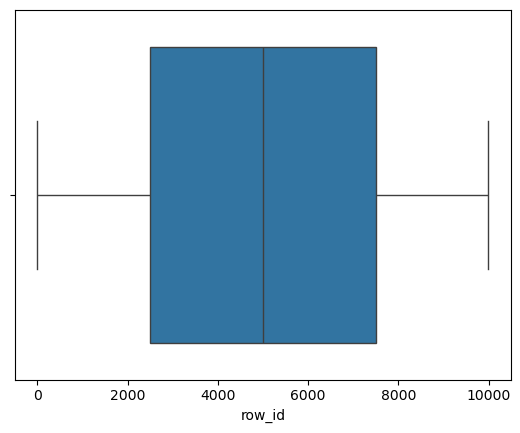

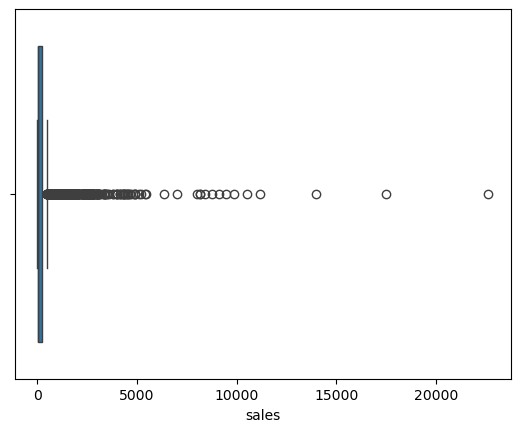

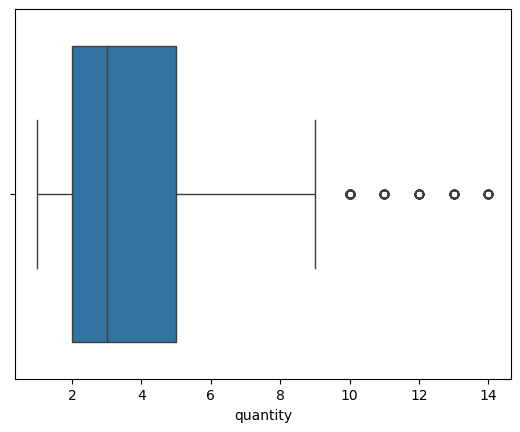

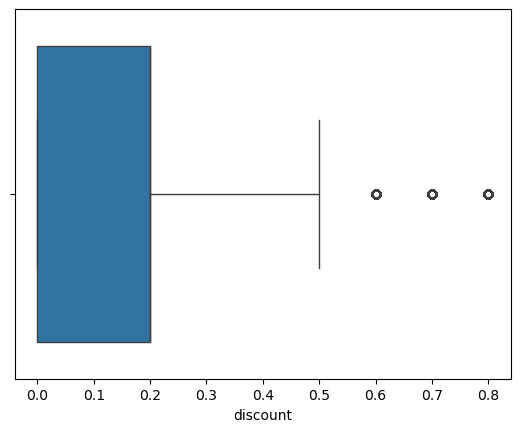

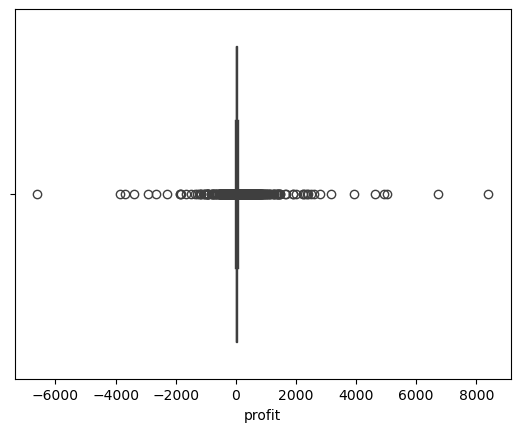

In [35]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

### Dropping unnecessary column

In [36]:
columns_to_drop = [
    "row_id",
    "order_id",
    "customer_id",
    "customer_name",
    "product_id",
    "product_name"
]

df = df.drop(columns=columns_to_drop)

In [37]:
df.head()

,order_date,ship_date,ship_mode,segment,country,city,state,postal_code,region,category,sub-category,sales,quantity,discount,profit
0,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,2016-06-16,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [38]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)
